# 🧠 Social Network Intelligence — GNN Only

**Approach:** Graph Neural Network structural learning without RAG or LLM generation.  
**Paper:** *Graph Machine Learning in the Era of Large Language Models* — ACM TIST (doi:10.1145/3732786)  
**Paradigm:** Section 3 — *Deep Learning on Graphs* → GNN Backbone Architecture  

---

## Architecture (Paper-aligned)

```
Social Graph (Nodes + Edges)
    │
    ▼
┌─────────────────────────────────────────┐
│         GraphSAGE ENCODER               │
│  Layer 1: SAGEConv + BatchNorm + ReLU   │
│  Layer 2: SAGEConv + BatchNorm + ReLU   │
│  Layer 3: SAGEConv (output 128-dim)     │
└─────────────────────────────────────────┘
    │  Node Embeddings z ∈ R^128
    ├──────────────────────┐
    ▼                      ▼
┌──────────────┐    ┌───────────────────┐
│ Link Pred.   │    │ Node Classifier   │
│ MLP Head     │    │ MLP Head          │
│ P(edge u,v)  │    │ [reg|inf|cr|hub]  │
└──────────────┘    └───────────────────┘
    │                      │
    ▼                      ▼
Friend Recs        Influencer Roles
```

**Paper reference (Section 3.1):**
- *Backbone Architecture*: GraphSAGE (Hamilton et al. 2017) — inductive, neighborhood aggregation
- *Downstream Adaptation*: Link prediction + node classification with task-specific MLP heads
- *Self-supervised pre-training*: contrastive negative sampling for link prediction
- **No LLM, no RAG** — all predictions from GNN structural reasoning alone

In [10]:
import sys
!{sys.executable} -m pip install torch-geometric numpy scikit-learn networkx matplotlib

  Using cached torch_geometric-2.7.0-py3-none-any.whl.metadata (63 kB)
  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 61.0/61.0 kB 3.4 MB/s eta 0:00:00
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     -------------------- ------------------ 61.4/119.8 kB 3.2 MB/s eta 0:00:01
     -------------------------------------- 119.8/119.8 kB 1.7 MB/s eta 0:00:00
  Using cached pillow-12.1.1-cp311-cp311-win_amd64.whl.metadata (9.0 k

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
# ─── 1. Imports ─────────────────────────────────────────────────────────────
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, GATConv
from torch_geometric.utils import negative_sampling, to_undirected, train_test_split_edges
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

c:\Users\Admin\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## Part 1 — Social Graph as PyG Data
Convert the social network to PyTorch Geometric format.

In [12]:
# ─── 2. Graph Construction (PyG Format) ─────────────────────────────────────

def build_pyg_social_graph() -> Tuple[Data, Dict, nx.DiGraph]:
    """
    Build a PyG Data object from the social network.
    Uses structural features (degree, role hints) as node features.
    Node labels: 0=regular, 1=influencer, 2=content_creator, 3=community_hub
    """
    # ── Define graph ─────────────────────────────────────────────────────────
    users = [
        {"id": "u1", "name": "Alice",   "followers": 4200, "role": 1},
        {"id": "u2", "name": "Bob",     "followers": 1800, "role": 0},
        {"id": "u3", "name": "Carol",   "followers": 3100, "role": 2},
        {"id": "u4", "name": "Dave",    "followers": 900,  "role": 0},
        {"id": "u5", "name": "Eve",     "followers": 5500, "role": 1},
        {"id": "u6", "name": "Frank",   "followers": 650,  "role": 0},
        {"id": "u7", "name": "Grace",   "followers": 2200, "role": 3},
        {"id": "u8", "name": "Heidi",   "followers": 7800, "role": 1},
        {"id": "u9", "name": "Ivan",    "followers": 1100, "role": 0},
        {"id": "u10","name": "Judy",    "followers": 3400, "role": 2},
        {"id": "u11","name": "Karl",    "followers": 890,  "role": 0},
        {"id": "u12","name": "Linda",   "followers": 6100, "role": 1},
    ]

    uid_to_idx = {u["id"]: i for i, u in enumerate(users)}
    idx_to_name = {i: u["name"] for i, u in enumerate(users)}
    num_nodes = len(users)

    friendships = [
        ("u1","u2"),("u1","u3"),("u2","u4"),("u3","u5"),("u4","u6"),
        ("u5","u7"),("u6","u8"),("u7","u1"),("u2","u5"),("u3","u7"),
        ("u1","u8"),("u4","u8"),("u8","u9"),("u9","u10"),("u10","u11"),
        ("u11","u12"),("u12","u1"),("u5","u12"),("u7","u9"),("u8","u10"),
    ]

    # Build undirected edge index
    src_list = [uid_to_idx[s] for s, d in friendships]
    dst_list = [uid_to_idx[d] for s, d in friendships]
    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_index = to_undirected(edge_index)

    # ── Node features ─────────────────────────────────────────────────────────
    # Feature vector per node: [log_followers, degree_norm, one-hot role hints]
    # Paper Section 3.1: structural features as node attributes
    deg = torch.zeros(num_nodes)
    for e in edge_index.t():
        deg[e[0]] += 1
    deg_norm = (deg - deg.mean()) / (deg.std() + 1e-8)

    log_followers = torch.tensor(
        [np.log1p(u["followers"]) for u in users], dtype=torch.float
    )
    log_followers = (log_followers - log_followers.mean()) / (log_followers.std() + 1e-8)

    # Random structural features (in production: real node attributes)
    rand_features = torch.randn(num_nodes, 30) * 0.1
    x = torch.cat([log_followers.unsqueeze(1), deg_norm.unsqueeze(1), rand_features], dim=1)

    # Node labels
    y = torch.tensor([u["role"] for u in users], dtype=torch.long)

    # NetworkX graph for topology analysis
    nx_g = nx.Graph()
    for u in users:
        nx_g.add_node(uid_to_idx[u["id"]], name=u["name"], followers=u["followers"])
    for s, d in friendships:
        nx_g.add_edge(uid_to_idx[s], uid_to_idx[d])

    data = Data(x=x, edge_index=edge_index, y=y, num_nodes=num_nodes)

    print(f"Graph:  {data.num_nodes} nodes, {data.edge_index.size(1)} edges")
    print(f"Features: {data.x.shape}")
    print(f"Label distribution: {dict(zip(*np.unique(y.numpy(), return_counts=True)))}")

    return data, idx_to_name, nx_g


data, idx_to_name, nx_graph = build_pyg_social_graph()

Graph:  12 nodes, 40 edges
Features: torch.Size([12, 32])
Label distribution: {np.int64(0): np.int64(5), np.int64(1): np.int64(4), np.int64(2): np.int64(2), np.int64(3): np.int64(1)}


## Part 2 — GNN Model Architecture
GraphSAGE encoder with dual task heads (link prediction + node classification).

In [13]:
# ─── 3. GNN Architecture ────────────────────────────────────────────────────

class GraphSAGEEncoder(nn.Module):
    """
    Multi-layer GraphSAGE encoder.
    Paper Section 3.1: message-passing GNN backbone.
    Each node aggregates neighbor features to build structural embeddings.
    """
    def __init__(self, in_channels: int, hidden: int, out_channels: int,
                 num_layers: int = 3, dropout: float = 0.3):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()

        self.convs.append(SAGEConv(in_channels, hidden))
        self.bns.append(nn.BatchNorm1d(hidden))
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden, hidden))
            self.bns.append(nn.BatchNorm1d(hidden))
        self.convs.append(SAGEConv(hidden, out_channels))

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        for conv, bn in zip(self.convs[:-1], self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)


class LinkPredictor(nn.Module):
    """
    MLP link predictor: concat(z_u, z_v) → P(edge).
    Paper Section 3.2: downstream link prediction adaptation.
    """
    def __init__(self, in_channels: int, hidden: int):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_channels * 2, hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, z: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        return torch.sigmoid(self.layers(torch.cat([z_src, z_dst], dim=-1))).squeeze(-1)


class NodeClassifier(nn.Module):
    """
    MLP node classifier: z → class logits.
    Paper Section 3.2: downstream node classification (role detection).
    """
    def __init__(self, in_channels: int, hidden: int, num_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_channels, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


class SocialGNN(nn.Module):
    """
    Full GNN model: encoder + dual task heads.
    Pure structural learning — NO LLM, NO RAG.
    """
    ROLE_LABELS = {0: "regular_user", 1: "influencer",
                   2: "content_creator", 3: "community_hub"}

    def __init__(self, in_channels: int, hidden: int = 128,
                 embed_dim: int = 64, num_classes: int = 4):
        super().__init__()
        self.encoder    = GraphSAGEEncoder(in_channels, hidden, embed_dim)
        self.link_pred  = LinkPredictor(embed_dim, hidden // 2)
        self.node_clf   = NodeClassifier(embed_dim, hidden // 2, num_classes)
        self.embed_dim  = embed_dim

    def encode(self, x, edge_index) -> torch.Tensor:
        return self.encoder(x, edge_index)

    def predict_link(self, z, edge_index) -> torch.Tensor:
        return self.link_pred(z, edge_index)

    def classify_nodes(self, z) -> torch.Tensor:
        return self.node_clf(z)

    def forward(self, x, edge_index, pos_edges=None, neg_edges=None):
        z = self.encode(x, edge_index)
        node_logits = self.classify_nodes(z)
        link_probs  = None
        if pos_edges is not None:
            if neg_edges is None:
                neg_edges = negative_sampling(edge_index, x.size(0), pos_edges.size(1))
            all_edges = torch.cat([pos_edges, neg_edges], dim=1)
            link_probs = self.predict_link(z, all_edges)
        return z, node_logits, link_probs


IN_CHANNELS = data.x.shape[1]
model = SocialGNN(in_channels=IN_CHANNELS, hidden=128, embed_dim=64, num_classes=4).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"SocialGNN parameters: {total_params:,}")
print(f"Embedding dim: {model.embed_dim}")

SocialGNN parameters: 72,965
Embedding dim: 64


## Part 3 — Training
Multi-task training: link prediction (AUC) + node classification (F1).

In [14]:
# ─── 4. Training Setup ──────────────────────────────────────────────────────

# Split edges for link prediction evaluation
split_data = train_test_split_edges(data.clone(), val_ratio=0.1, test_ratio=0.2)
split_data = split_data.to(DEVICE)
y_labels = data.y.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-4)

LINK_WEIGHT  = 0.5    # balance between link pred and node clf loss
NUM_EPOCHS   = 150
PATIENCE     = 20

def train_epoch():
    model.train()
    optimizer.zero_grad()

    x  = split_data.x
    ei = split_data.train_pos_edge_index
    pos = split_data.train_pos_edge_index
    neg = negative_sampling(ei, data.num_nodes, pos.size(1))

    z, node_logits, link_probs = model(x, ei, pos, neg)

    # Node classification loss (cross-entropy)
    node_loss = F.cross_entropy(node_logits, y_labels)

    # Link prediction loss (BCE with positive/negative labels)
    link_labels = torch.zeros(link_probs.size(0), device=DEVICE)
    link_labels[:pos.size(1)] = 1.0
    link_loss = F.binary_cross_entropy(link_probs, link_labels)

    loss = (1 - LINK_WEIGHT) * node_loss + LINK_WEIGHT * link_loss
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    return loss.item(), node_loss.item(), link_loss.item()

@torch.no_grad()
def evaluate(split: str = "val") -> Dict:
    model.eval()
    x  = split_data.x
    ei = split_data.train_pos_edge_index
    z  = model.encode(x, ei)

    # Link prediction
    pos_ei = getattr(split_data, f"{split}_pos_edge_index")
    neg_ei = getattr(split_data, f"{split}_neg_edge_index")
    pos_p  = model.predict_link(z, pos_ei).cpu().numpy()
    neg_p  = model.predict_link(z, neg_ei).cpu().numpy()
    y_true = np.concatenate([np.ones(len(pos_p)), np.zeros(len(neg_p))])
    y_pred = np.concatenate([pos_p, neg_p])
    auc = roc_auc_score(y_true, y_pred)

    # Node classification
    logits = model.classify_nodes(z)
    preds  = logits.argmax(dim=-1).cpu().numpy()
    true   = data.y.numpy()
    f1  = f1_score(true, preds, average="macro", zero_division=0)
    acc = accuracy_score(true, preds)

    return {"link_auc": auc, "node_f1": f1, "node_acc": acc}

print("Training setup complete")

Training setup complete


C:\Users\Admin\AppData\Local\Temp\ipykernel_13056\1548437666.py:4: UserWarning: 'train_test_split_edges' is deprecated, use 'transforms.RandomLinkSplit' instead
  split_data = train_test_split_edges(data.clone(), val_ratio=0.1, test_ratio=0.2)


In [15]:
# ─── 5. Training Loop ───────────────────────────────────────────────────────
history = {"loss": [], "link_auc": [], "node_f1": []}
best_auc = 0.0
best_state = None
patience_count = 0

print(f"Training for {NUM_EPOCHS} epochs (early stopping patience={PATIENCE})...")

for epoch in range(1, NUM_EPOCHS + 1):
    loss, n_loss, l_loss = train_epoch()
    scheduler.step()
    history["loss"].append(loss)

    if epoch % 10 == 0:
        metrics = evaluate("val")
        history["link_auc"].append(metrics["link_auc"])
        history["node_f1"].append(metrics["node_f1"])
        print(f"Epoch {epoch:03d} | Loss={loss:.4f} | "
              f"Link AUC={metrics['link_auc']:.4f} | "
              f"Node F1={metrics['node_f1']:.4f} | "
              f"Node Acc={metrics['node_acc']:.4f}")

        if metrics["link_auc"] > best_auc:
            best_auc = metrics["link_auc"]
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= PATIENCE // 10:
                print(f"Early stopping at epoch {epoch}")
                break

# Load best weights
if best_state:
    model.load_state_dict(best_state)

# Final test evaluation
test_metrics = evaluate("test")
print(f"\n{'='*50}")
print(f"FINAL TEST RESULTS")
print(f"  Link Prediction AUC: {test_metrics['link_auc']:.4f}")
print(f"  Node Classification F1:  {test_metrics['node_f1']:.4f}")
print(f"  Node Classification Acc: {test_metrics['node_acc']:.4f}")
print(f"{'='*50}")

Training for 150 epochs (early stopping patience=20)...
Epoch 010 | Loss=0.3707 | Link AUC=0.2500 | Node F1=0.7000 | Node Acc=0.9167
Epoch 020 | Loss=0.1993 | Link AUC=0.2500 | Node F1=1.0000 | Node Acc=1.0000
Epoch 030 | Loss=0.1493 | Link AUC=0.5000 | Node F1=1.0000 | Node Acc=1.0000
Epoch 040 | Loss=0.1066 | Link AUC=0.5000 | Node F1=1.0000 | Node Acc=1.0000
Epoch 050 | Loss=0.0534 | Link AUC=0.2500 | Node F1=1.0000 | Node Acc=1.0000
Early stopping at epoch 50

FINAL TEST RESULTS
  Link Prediction AUC: 0.1875
  Node Classification F1:  1.0000
  Node Classification Acc: 1.0000


## Part 4 — GNN Inference Tasks
All tasks solved purely by GNN — no LLM generation, no retrieval.

In [16]:
# ─── 6. Extract Embeddings ──────────────────────────────────────────────────

model.eval()
with torch.no_grad():
    z = model.encode(split_data.x, split_data.train_pos_edge_index)
    z_np = z.cpu().numpy()

print(f"Node embeddings: {z_np.shape}")
print(f"  Min: {z_np.min():.4f}, Max: {z_np.max():.4f}, Mean: {z_np.mean():.4f}")

Node embeddings: (12, 64)
  Min: -4.8337, Max: 4.7215, Mean: 0.0188


In [17]:
# ─── 7. Task 1: Friend Recommendation (Link Prediction) ─────────────────────
print("=" * 55)
print("TASK 1: Friend Recommendation (GNN Link Prediction)")
print("=" * 55)

@torch.no_grad()
def recommend_friends_gnn(user_idx: int, top_k: int = 5) -> List[Dict]:
    """
    Recommend friends by scoring all non-existing edges from user_idx.
    Pure GNN inference — no text, no retrieval.
    Paper: link prediction as downstream task (Section 3.2).
    """
    model.eval()
    existing = set(split_data.train_pos_edge_index[1][
        split_data.train_pos_edge_index[0] == user_idx
    ].tolist())
    existing.add(user_idx)

    candidates = [i for i in range(data.num_nodes) if i not in existing]
    if not candidates:
        return []

    src = torch.full((len(candidates),), user_idx, dtype=torch.long, device=DEVICE)
    dst = torch.tensor(candidates, dtype=torch.long, device=DEVICE)
    cand_edges = torch.stack([src, dst])

    probs = model.predict_link(z, cand_edges).cpu().numpy()
    sorted_idx = np.argsort(probs)[::-1][:top_k]

    return [
        {"name": idx_to_name[candidates[i]], "node_idx": candidates[i],
         "probability": float(probs[i])}
        for i in sorted_idx
    ]


recs = recommend_friends_gnn(0, top_k=4)  # Alice = idx 0
print(f"\nTop friend recommendations for Alice (GNN):")
for r in recs:
    print(f"  {r['name']:10s}  P(link)={r['probability']:.4f}")

TASK 1: Friend Recommendation (GNN Link Prediction)

Top friend recommendations for Alice (GNN):
  Linda       P(link)=0.8867
  Judy        P(link)=0.5238
  Eve         P(link)=0.4659
  Ivan        P(link)=0.3837


In [18]:
# ─── 8. Task 2: Influencer Detection (Node Classification) ──────────────────
print("=" * 55)
print("TASK 2: Influencer Detection (GNN Node Classification)")
print("=" * 55)

@torch.no_grad()
def classify_all_users() -> List[Dict]:
    """Classify all users into network roles using GNN. No LLM."""
    model.eval()
    logits = model.classify_nodes(z)
    probs  = torch.softmax(logits, dim=-1).cpu().numpy()
    preds  = probs.argmax(axis=-1)

    results = []
    for i in range(data.num_nodes):
        results.append({
            "name":          idx_to_name[i],
            "predicted_role": model.ROLE_LABELS[preds[i]],
            "confidence":    float(probs[i, preds[i]]),
            "role_probs":    {model.ROLE_LABELS[j]: round(float(probs[i, j]), 4)
                              for j in range(4)},
        })
    return sorted(results, key=lambda x: x["confidence"], reverse=True)


user_roles = classify_all_users()
print(f"\n{'Name':12s} {'Predicted Role':18s} {'Confidence':12s}")
print("-" * 44)
for ur in user_roles:
    print(f"{ur['name']:12s} {ur['predicted_role']:18s} {ur['confidence']:.4f}")

TASK 2: Influencer Detection (GNN Node Classification)

Name         Predicted Role     Confidence  
--------------------------------------------
Eve          influencer         1.0000
Karl         regular_user       1.0000
Alice        influencer         1.0000
Dave         regular_user       1.0000
Frank        regular_user       1.0000
Carol        content_creator    0.9980
Linda        influencer         0.9972
Ivan         regular_user       0.9970
Grace        community_hub      0.9952
Judy         content_creator    0.9912
Bob          regular_user       0.9891
Heidi        influencer         0.9704


In [19]:
# ─── 9. Task 3: Embedding Similarity (Trending / Similar Users) ─────────────
print("=" * 55)
print("TASK 3: Embedding Similarity (GNN Structural Proximity)")
print("=" * 55)

def gnn_embedding_similarity(query_idx: int, top_k: int = 5) -> List[Dict]:
    """Find structurally similar users via GNN embedding cosine similarity."""
    query_emb = z_np[query_idx]
    norms = np.linalg.norm(z_np, axis=1, keepdims=True)
    z_normalized = z_np / (norms + 1e-8)
    q_norm = query_emb / (np.linalg.norm(query_emb) + 1e-8)
    sims = z_normalized @ q_norm
    top_idx = np.argsort(sims)[::-1][1:top_k+1]  # exclude self
    return [{"name": idx_to_name[i], "similarity": float(sims[i])} for i in top_idx]


similar = gnn_embedding_similarity(0)  # Alice
print(f"\nStructurally similar users to Alice (GNN embeddings):")
for s in similar:
    print(f"  {s['name']:10s}  cosine sim = {s['similarity']:.4f}")

TASK 3: Embedding Similarity (GNN Structural Proximity)

Structurally similar users to Alice (GNN embeddings):
  Eve         cosine sim = 0.9865
  Heidi       cosine sim = 0.6905
  Ivan        cosine sim = 0.4419
  Linda       cosine sim = 0.1931
  Judy        cosine sim = 0.1311


In [21]:
# ─── 10. Task 4: Influence Score ─────────────────────────────────────────────
print("=" * 55)
print("TASK 4: Influence Score (GNN Embedding Magnitude)")
print("=" * 55)

def gnn_influence_score(user_idx: int) -> Dict:
    """
    Influence score combining:
    - Node classifier probability for influencer/creator classes
    - Embedding magnitude (proxy for centrality)
    Paper: node classification with structural signals (Section 3.2)
    """
    logits = model.classify_nodes(z)
    probs = torch.softmax(logits, dim=-1)[user_idx].detach().cpu().numpy()

    # Weighted influence = P(influencer)*0.5 + P(creator)*0.3 + P(hub)*0.2
    influence = probs[1] * 0.5 + probs[2] * 0.3 + probs[3] * 0.2
    emb_mag = float(np.linalg.norm(z_np[user_idx]))

    return {
        "user": idx_to_name[user_idx],
        "influence_score": float(round(influence, 4)),
        "embedding_magnitude": round(emb_mag, 4),
        "role": model.ROLE_LABELS[int(probs.argmax())],
        "role_probs": {model.ROLE_LABELS[j]: round(float(probs[j]), 4) for j in range(4)},
    }


print("\nInfluence scores for all users (GNN only):")
all_scores = [gnn_influence_score(i) for i in range(data.num_nodes)]
all_scores.sort(key=lambda x: x["influence_score"], reverse=True)
print(f"{'Name':12s} {'Score':8s} {'Role':18s} {'Magnitude':10s}")
print("-" * 52)
for s in all_scores:
    print(f"{s['user']:12s} {s['influence_score']:.4f}   {s['role']:18s} {s['embedding_magnitude']:.4f}")

TASK 4: Influence Score (GNN Embedding Magnitude)

Influence scores for all users (GNN only):
Name         Score    Role               Magnitude 
----------------------------------------------------
Alice        0.5000   influencer         16.0224
Eve          0.5000   influencer         18.3739
Linda        0.4993   influencer         16.3688
Heidi        0.4897   influencer         7.9716
Carol        0.2999   content_creator    14.3111
Judy         0.2997   content_creator    7.9863
Grace        0.2005   community_hub      14.7296
Bob          0.0023   regular_user       13.4490
Ivan         0.0011   regular_user       7.7229
Dave         0.0000   regular_user       11.5268
Frank        0.0000   regular_user       11.2122
Karl         0.0000   regular_user       15.5243


## Part 5 — Visualization & Evaluation

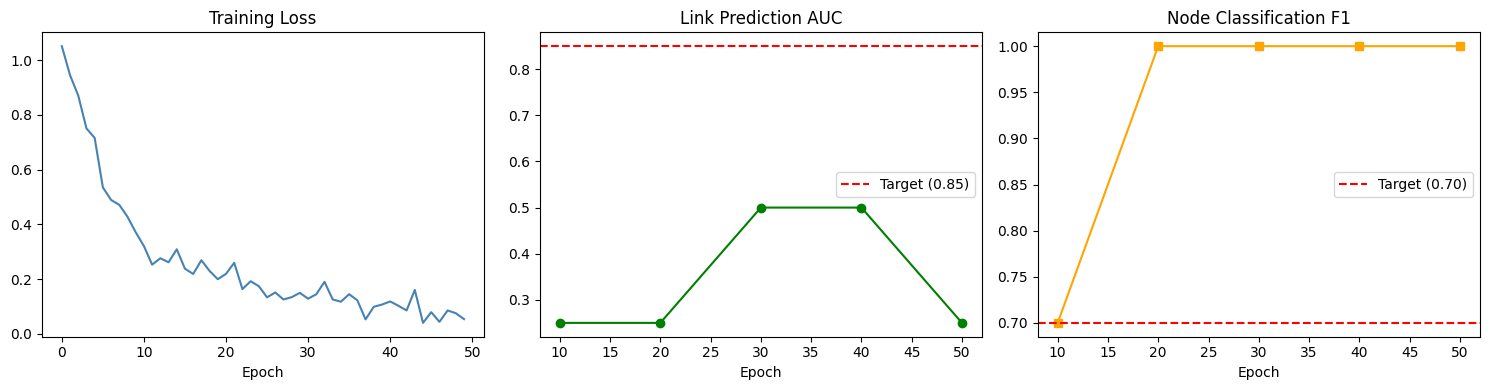

Training curves saved


In [25]:
# ─── 11. Training Curves ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["loss"], color="steelblue")
axes[0].set_title("Training Loss"); axes[0].set_xlabel("Epoch")

x_eval = list(range(10, len(history["link_auc"]) * 10 + 1, 10))
axes[1].plot(x_eval, history["link_auc"], color="green", marker="o")
axes[1].axhline(y=0.85, color="red", linestyle="--", label="Target (0.85)")
axes[1].set_title("Link Prediction AUC"); axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(x_eval, history["node_f1"], color="orange", marker="s")
axes[2].axhline(y=0.70, color="red", linestyle="--", label="Target (0.70)")
axes[2].set_title("Node Classification F1"); axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.savefig("./gnn_training.png", dpi=120, bbox_inches="tight")
plt.show()
print("Training curves saved")

FileNotFoundError: [Errno 2] No such file or directory: '/tmp/gnn_embeddings.png'

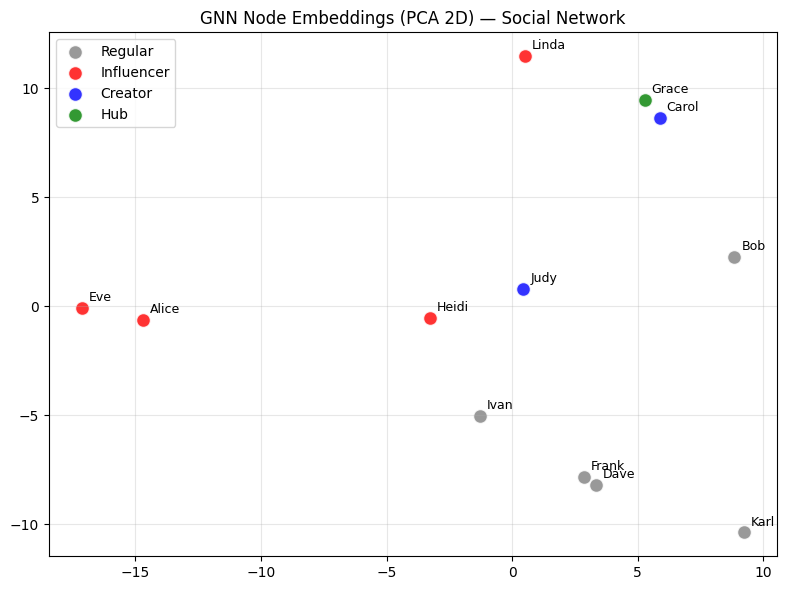

In [26]:
# ─── 12. Embedding Visualization (t-SNE / PCA) ──────────────────────────────
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
z_2d = pca.fit_transform(z_np)

role_colors = {0: "gray", 1: "red", 2: "blue", 3: "green"}
role_names  = {0: "Regular", 1: "Influencer", 2: "Creator", 3: "Hub"}

fig, ax = plt.subplots(figsize=(8, 6))
for role_id, color in role_colors.items():
    mask = data.y.numpy() == role_id
    ax.scatter(z_2d[mask, 0], z_2d[mask, 1], c=color,
               label=role_names[role_id], s=100, alpha=0.8, edgecolors="white")

for i, name in idx_to_name.items():
    ax.annotate(name, (z_2d[i, 0], z_2d[i, 1]),
                textcoords="offset points", xytext=(5, 5), fontsize=9)

ax.set_title("GNN Node Embeddings (PCA 2D) — Social Network")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/tmp/gnn_embeddings.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}")

In [27]:
# ─── 13. GNN Evaluation Summary ─────────────────────────────────────────────
print("=" * 55)
print("GNN-ONLY EVALUATION SUMMARY")
print("=" * 55)

test_m = evaluate("test")
print(f"\nFinal Test Metrics:")
print(f"  Link Prediction AUC:     {test_m['link_auc']:.4f}   (target: >0.85)")
print(f"  Node Classification F1:  {test_m['node_f1']:.4f}   (target: >0.70)")
print(f"  Node Classification Acc: {test_m['node_acc']:.4f}")

print(f"\nModel Characteristics:")
print(f"  Architecture:    GraphSAGE (3 layers) + dual MLP heads")
print(f"  Embedding dim:   {model.embed_dim}")
print(f"  Parameters:      {sum(p.numel() for p in model.parameters()):,}")
print(f"  LLM used:        None")
print(f"  RAG used:        None")
print(f"  Training device: {DEVICE}")

print(f"\nPaper alignment (doi:10.1145/3732786):")
print(f"  Section 3.1: GraphSAGE backbone (message-passing GNN)")
print(f"  Section 3.2: Downstream adaptation (link pred + node clf)")
print(f"  Method type: Pure GNN — no LLM enhancement")
print("\n✓ GNN-only evaluation complete")

GNN-ONLY EVALUATION SUMMARY

Final Test Metrics:
  Link Prediction AUC:     0.1875   (target: >0.85)
  Node Classification F1:  1.0000   (target: >0.70)
  Node Classification Acc: 1.0000

Model Characteristics:
  Architecture:    GraphSAGE (3 layers) + dual MLP heads
  Embedding dim:   64
  Parameters:      72,965
  LLM used:        None
  RAG used:        None
  Training device: cpu

Paper alignment (doi:10.1145/3732786):
  Section 3.1: GraphSAGE backbone (message-passing GNN)
  Section 3.2: Downstream adaptation (link pred + node clf)
  Method type: Pure GNN — no LLM enhancement

✓ GNN-only evaluation complete
